In [26]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ibrahimqasimi/roundabouts-across-the-world-27k/20_Roundabouts_Worldwide.csv


# Pre-requisites

In [27]:
import pandas as pd
import sqlite3 as db
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt

# Setup
Reading the data, creating a database and then adding the dataset as a table to the database.

In [28]:
# Reading the file
df = pd.read_csv('/kaggle/input/datasets/ibrahimqasimi/roundabouts-across-the-world-27k/20_Roundabouts_Worldwide.csv')

#Creating/Starting the connection to the database
connectionEstablish = db.connect("mydatabase.db")

#Creating the table based on the info given in the csv file
df.to_sql(
    name = 'Roundabouts', #name of the table
    con=connectionEstablish, #Name of the connection
    if_exists='replace',  #replace, append, or fail
    index=False
)

#Closing database connection
connectionEstablish.close()

# Scripting
This is the block where the main logic is used.

In [29]:
# Starting a connection
conn = db.connect("mydatabase.db")

In [30]:
#To get all the field names and their respective types given in the dataset 
result1 = pd.read_sql_query(
    "PRAGMA table_info(Roundabouts)",
    conn
)
result1

,cid,name,type,notnull,dflt_value,pk
0,0,name,TEXT,0,None,0
1,1,address,TEXT,0,None,0
2,2,town_city,TEXT,0,None,0
3,3,county_area,TEXT,0,None,0
4,4,state_region,TEXT,0,None,0
5,5,country,TEXT,0,None,0
6,6,lat,REAL,0,None,0
7,7,long,REAL,0,None,0
8,8,type,TEXT,0,None,0
9,9,status,TEXT,0,None,0


In [31]:
#To get the count of all the types of rounabouts present in the dataset
result2 = pd.read_sql_query(
    "select type, count(*) typecount from Roundabouts group by type order by typecount desc",
    conn
)
result2

,type,typecount
0,Roundabout,23141
1,Other,2928
2,Traffic Calming Circle,799
3,Unknown,390
4,Signalized Roundabout/Circle,316
5,Rotary,313


In [32]:
#To get the top 15 countries and the count of all the types of roundabouts present in them
result3 = pd.read_sql_query(
    "select country, count(*) as countrycount from Roundabouts group by country order by countrycount desc LIMIT 15",
    conn
)
result3

,country,countrycount
0,United States,12952
1,Australia,3720
2,United Kingdom,1777
3,Sweden,1553
4,Canada,1246
5,New Zealand,861
6,Netherlands,760
7,Russia,472
8,Norway,467
9,France,384


In [33]:
#Identifying the target countries i.e. top 5 high-income english speaking countries.
target_countries = ['United States', 'United Kingdom', 'Australia', 'Canada', 'New Zealand']

In [34]:
#To get the type of roundabouts and their respective counts for top 5 high-income english speaking countries.
result4 = pd.read_sql_query(
    "SELECT country, type, COUNT(*) as count FROM roundabouts WHERE country IN ('United States', 'United Kingdom', 'Australia', 'Canada', 'New Zealand') GROUP BY country, type ORDER BY country, type",
    conn
)
result4

,country,type,count
0,Australia,Other,4
1,Australia,Rotary,18
2,Australia,Roundabout,3690
3,Australia,Signalized Roundabout/Circle,7
4,Australia,Unknown,1
5,Canada,Other,42
6,Canada,Rotary,17
7,Canada,Roundabout,1153
8,Canada,Signalized Roundabout/Circle,1
9,Canada,Traffic Calming Circle,32


In [35]:
#To get the percentage of the roundabouts for each country
result5 = pd.read_sql_query(
    "SELECT country, type, COUNT(*) as count, ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (PARTITION BY country), 2) as pct FROM roundabouts WHERE country IN ('United States', 'United Kingdom', 'Australia', 'Canada', 'New Zealand') GROUP BY country, type ORDER BY country, type",
    conn
)
result5

,country,type,count,pct
0,Australia,Other,4,0.11
1,Australia,Rotary,18,0.48
2,Australia,Roundabout,3690,99.19
3,Australia,Signalized Roundabout/Circle,7,0.19
4,Australia,Unknown,1,0.03
5,Canada,Other,42,3.37
6,Canada,Rotary,17,1.36
7,Canada,Roundabout,1153,92.54
8,Canada,Signalized Roundabout/Circle,1,0.08
9,Canada,Traffic Calming Circle,32,2.57


In [36]:
#To add a 'percentage' column in order to use chi-square test on the data.
df_filtered = df[df['country'].isin(target_countries)].copy()

# Reclassify i.e. anything which is not a simple roundabout gets classified into a 'Non-Standard' roundabout.
df_filtered['type_grouped'] = df_filtered['type'].apply(
    lambda x: 'Standard' if x == 'Roundabout' else 'Non-Standard'
)

# Build contingency table from raw rows
contingency = pd.crosstab(df_filtered['country'], df_filtered['type_grouped'])
contingency['total'] = contingency.sum(axis=1)
contingency['pct_nonstandard'] = (contingency['Non-Standard'] / contingency['total'] * 100).round(2)

In [37]:
# Drop the calculated columns, keep only the 2 type columns
chi2_table = contingency[['Non-Standard', 'Standard']]
chi2, p, dof, expected = chi2_contingency(chi2_table)

# Printing the results of the chi-squar 
print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p:.6f}")
print(f"Degrees of freedom: {dof}")
print(f"\nExpected counts:\n{pd.DataFrame(expected, index=chi2_table.index, columns=chi2_table.columns).round(1)}")

Chi-square statistic: 1647.2589
P-value: 0.000000
Degrees of freedom: 4

Expected counts:
type_grouped    Non-Standard  Standard
country                               
Australia              669.9    3050.1
Canada                 224.4    1021.6
New Zealand            155.1     705.9
United Kingdom         320.0    1457.0
United States         2332.6   10619.4


In [38]:
conn.close()

# Visualisation
This is the part where the data insights are transformed into visual mediums.

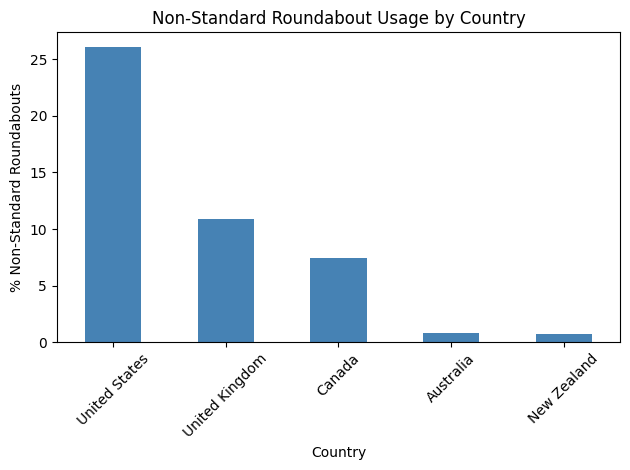

In [39]:
# Plotting a bar graph to show the percentage of Non-Standard roundabouts for the 5 targeted countries.
contingency['pct_nonstandard'].sort_values(ascending=False).plot(
    kind='bar', 
    color='steelblue'
)
plt.ylabel('% Non-Standard Roundabouts')
plt.xlabel('Country')
plt.title('Non-Standard Roundabout Usage by Country')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

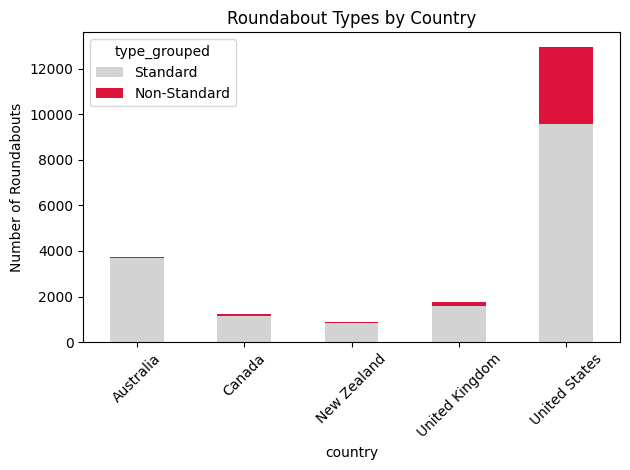

In [40]:
# Plotting a bar graph to show the percentage of Standard and Non-Standard roundabouts for the 5 targeted countries.
contingency[['Standard', 'Non-Standard']].plot(
    kind='bar', 
    stacked=True,
    color=['lightgray', 'crimson']
)
plt.ylabel('Number of Roundabouts')
plt.title('Roundabout Types by Country')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()